# Data Loading and Cleaning

## Heart Disease Dataset

This lab focuses on loading, inspecting, cleaning, and preparing the Heart Disease dataset for machine learning tasks. The dataset contains medical information of patients and is used to predict whether a patient has heart disease or not.

The task includes:
- Handling missing values
- Removing duplicates
- Standardizing data
- Separating features and target variable
- Saving cleaned data

Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Step 2: Load Dataset

In [2]:
df = pd.read_csv("heart-2 - heart-2.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Dataset Overview

The Heart Disease dataset contains medical records of patients including age, cholesterol level, blood pressure, chest pain type, and other health-related attributes.

The target variable:
- 1 = Heart disease present
- 0 = No heart disease

This is a classification problem because the output contains categories.

Step 3: Inspect Shape and Data Types

In [3]:
print("Dataset Shape:", df.shape)
df.info()

Dataset Shape: (1025, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## Initial Inspection

- `df.shape` shows the number of rows and columns.
- `df.info()` helps identify:
  - data types
  - missing values
  - non-null counts

This step is important before cleaning the dataset.

Step 4: Summary Statistics

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


# Summary Statistics

The summary statistics help us understand:
- Mean
- Standard deviation
- Minimum and maximum values
- Quartiles

This also helps identify possible outliers in the dataset.

Step 5: Check Missing Values

In [5]:
missing_values = df.isnull().sum()
print(missing_values)

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Step 6: Handle Missing Values

In [6]:
# Fill numerical missing values using median
num_cols = df.select_dtypes(include=np.number).columns
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\HP\AppData\Local\Temp\ipykernel_1044\2598901210.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


## Handling Missing Values

Missing numerical values were replaced using the median.

Median is preferred because:
- it is less affected by outliers
- it gives more robust results for skewed medical data

Step 7: Check Duplicate Rows

In [7]:
duplicates = df.duplicated().sum()

print("Duplicate Rows:", duplicates)

Duplicate Rows: 723


Step 8: Remove Duplicates

In [8]:
df.drop_duplicates(inplace=True)

print("Shape After Removing Duplicates:", df.shape)

Shape After Removing Duplicates: (302, 14)


## Duplicate Removal

Duplicate rows can negatively affect machine learning models because repeated records may bias the results.

Therefore, duplicate rows were removed.

Step 9: Check Data Types Again

In [9]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Step 10: Standardize Column Names

In [10]:
df.columns = df.columns.str.strip().str.lower()
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

## Data Standardization

Column names were standardized by:
- removing extra spaces
- converting to lowercase

This improves consistency and avoids errors during analysis.

Step 11: Check Impossible Values

In [11]:
# Example checks

print(df[df['age'] < 0])
print(df[df['chol'] < 0])
print(df[df['trestbps'] < 0])

Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []
Empty DataFrame
Columns: [age, sex, cp, trestbps, chol, fbs, restecg, thalach, exang, oldpeak, slope, ca, thal, target]
Index: []


## Invalid Value Checking

Medical datasets should not contain impossible values such as:
- negative age
- negative cholesterol
- negative blood pressure

These values were checked to ensure data quality.

Step 12: Visualize Distribution

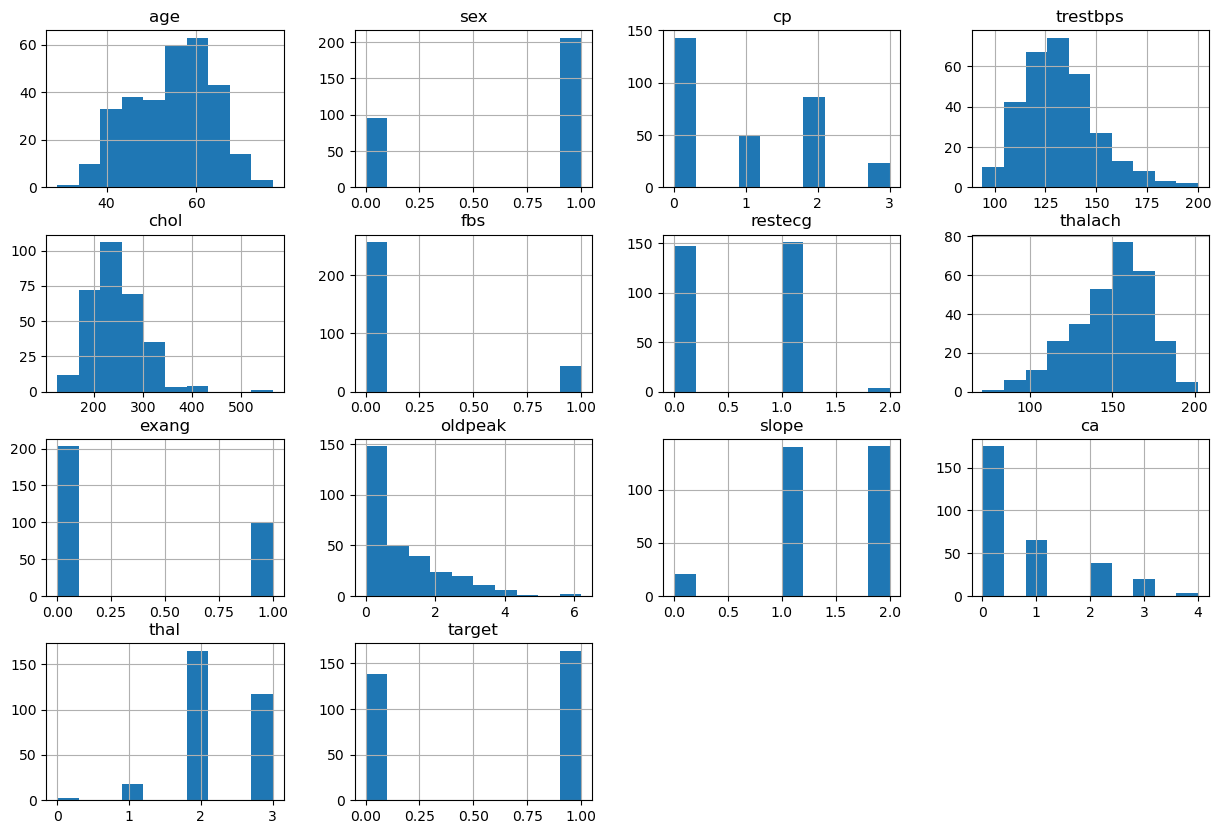

In [12]:
df.hist(figsize=(15,10))
plt.show()

## Data Distribution

Histograms were used to inspect:
- distribution of variables
- skewness
- possible outliers

Visualization helps understand the dataset better before modeling.

Step 13: Separate Features and Target

In [13]:
target_col = 'target'
X = df.drop(columns=[target_col])
y = df[target_col]
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (302, 13)
Target Shape: (302,)


## Feature and Target Separation

The dataset was divided into:
- X = input features
- y = target variable

The target column is `target`, which indicates presence or absence of heart disease.

This step is required for supervised machine learning.

Step 14: Save Cleaned Dataset

In [14]:
df.to_csv("heart_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


# Final Summary

In this lab:
- The dataset was loaded successfully
- Missing values were identified and handled
- Duplicate rows were removed
- Data was standardized
- Invalid values were checked
- Features and target variables were separated
- The cleaned dataset was saved for future analysis

The cleaned data is now ready for:
- Exploratory Data Analysis (EDA)
- Machine Learning models
- Classification tasks